# 📝 Resumen Ejecutivo: Modelo Baseline VARX (Vector Autoregression)

Este notebook documenta la preparación, entrenamiento y evaluación del modelo estadístico multivariante **VARX** (Vector Autoregression con variables exógenas). Este algoritmo actúa como nuestro **modelo base (baseline)** para establecer las métricas de referencia contra las que competirán los modelos avanzados de Machine Learning (XGBoost) y Deep Learning (LSTM) del proyecto.

### 🛠️ Hitos Metodológicos Alcanzados:

* **Preprocesamiento Estricto:** Se forzó la equidistancia temporal fijando la frecuencia horaria y se solucionaron los huecos de sensórica mediante interpolación lineal (evitando *Data Leakage* al ordenar estrictamente el índice).
* **Prueba de Estacionariedad:** El **Test de Dickey-Fuller Aumentado (ADF)** demostró estadísticamente (p-valor = 0.0000) que las 12 variables endógenas (intensidad, ocupación, velocidad) son estacionarias por la propia naturaleza física acotada del tráfico. Esto nos permitió entrenar el modelo con los datos en crudo sin necesidad de aplicar diferenciación matemática.
* **Ajuste de Dimensionalidad (Lags):** Se evaluaron empíricamente dos ventanas históricas (48h y 168h). Se descartó el modelo VAR(168) tras comprobar que sufría la **Maldición de la Dimensionalidad**: la necesidad de estimar más de 24.000 parámetros provocaba un sobreajuste masivo que colapsaba la capacidad predictiva a futuro (R² medio del 15%). Se designó el **VAR(48)** como el modelo definitivo por su equilibrio entre memoria inercial y robustez matemática.
* **Predicción Multi-Horizonte (1h, 24h, 168h):** Se realizaron las inferencias proyectando dinámicamente el histórico de las variables endógenas y proporcionando el contexto de calendario (variables exógenas deterministas) para las horas futuras a predecir.

### 📊 Conclusiones del Rendimiento:
El modelo VAR(48) demuestra una excelente capacidad para seguir el ciclo circadiano y semanal del tráfico en vías con comportamiento regular (alcanzando métricas de **R² > 0.80** a una semana vista para los sensores 3820 y 6782). No obstante, el desplome de métricas en el **Sensor 6642** (R² negativo) pone en evidencia la principal debilidad de la estadística lineal clásica: su gran vulnerabilidad y ceguera ante anomalías o cortes físicos de la vía, justificando la necesidad técnica de explorar arquitecturas más flexibles en los siguientes notebooks.

# 📝 Resumen Ejecutivo: Modelo Baseline VARX (Vector Autoregression)

Este notebook documenta la preparación, entrenamiento y evaluación del modelo estadístico multivariante **VARX**. Actúa como nuestro **modelo base (baseline)**.

### 🛠️ Hitos Metodológicos:
* **Preprocesamiento:** Frecuencia horaria estricta e interpolación lineal de nulos. Se exportan los datos limpios para unificar el punto de partida del resto de modelos.
* **Estacionariedad:** Test de Dickey-Fuller Aumentado (ADF) superado (p-valor = 0.0000).
* **Selección Dinámica de Ventana (Lags):** Se estableció un límite de seguridad de 48 horas para evitar la Maldición de la Dimensionalidad observada en ventanas de 168h. Se delegó la elección del rezago óptimo al **Criterio de Información de Akaike (AIC)**, permitiendo al algoritmo ajustar su propia memoria histórica.
* **Predicción Multi-Horizonte:** Inferencias a 1h, 24h y 168h usando contexto de calendario (variables exógenas deterministas).

# Paso 1: Cargue de csv y preparacion de entorno

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
 
# Cargue de los csvs
train_df = pd.read_csv('../../data/processed/Split_Datasets/data_train.csv')
val_df = pd.read_csv('../../data/processed/Split_Datasets/data_val.csv')
test_df = pd.read_csv('../../data/processed/Split_Datasets/data_test.csv')

#Creamos funcion para configurar el indice temporal
def preparar_indice_temporal(df):
    """
    Convierte la columna 'fecha' en el índice del DataFrame,
    lo ordena cronológicamente y fuerza una frecuencia horaria ('h').
    """
    # 1. Convertir a formato fecha (datetime)
    df['fecha'] = pd.to_datetime(df['fecha'])
    
    # 2. Establecer como índice
    df.set_index('fecha', inplace=True)
    
    # 3. Ordenar cronologicamente
    df.sort_index(inplace=True)
    
    # 4. Forzar la frecuencia horaria ('h')
    # Esto es OBLIGATORIO para que statsmodels entienda qué es un "lag" (rezago)
    df = df.asfreq('h')    
    
    return df

# Aplicamos la transformacion a los 3 splits
train_df = preparar_indice_temporal(train_df)
val_df = preparar_indice_temporal(val_df)
test_df = preparar_indice_temporal(test_df)

# Separacion VARX: Endogenas (12) y Exogenas
cols_endogenas = [col for col in train_df.columns if 'intensidad' in col or 'ocupacion' in col or 'vmed' in col]

# Variables de calendario (X) - El contexto temporal
cols_exogenas = ['hora', 'dia_semana', 'mes', 'es_finde']

# Mostrar resumen para validar la estructura matemática
print("--- DIMENSIONES Y ESTRUCTURA TEMPORAL ---")
print(f"Train: {train_df.shape} | Inicio: {train_df.index.min()} | Fin: {train_df.index.max()}")
print(f"Val:   {val_df.shape}  | Inicio: {val_df.index.min()} | Fin: {val_df.index.max()}")
print(f"Test:  {test_df.shape}  | Inicio: {test_df.index.min()} | Fin: {test_df.index.max()}\n")

print(f"Total Variables Endógenas ({len(cols_endogenas)}): {cols_endogenas}")
print(f"Total Variables Exógenas  ({len(cols_exogenas)}): {cols_exogenas}")

# Breve chequeo de valores nulos generados por asfreq('H')
nulos_train = train_df[cols_endogenas].isnull().sum().sum()
if nulos_train > 0:
    print(f"\n⚠️ ATENCIÓN: Al forzar la frecuencia horaria, se han detectado {nulos_train} valores nulos en Train.")
else:
    print("\n✅ Datos estructurados correctamente. Cero valores nulos detectados tras fijar la frecuencia.")

# Nulos Val
nulos_val = val_df[cols_endogenas].isnull().sum().sum()
if nulos_val > 0:
    print(f"\n⚠️ ATENCIÓN: Al forzar la frecuencia horaria, se han detectado {nulos_val} valores nulos en Train.")
else:
    print("\n✅ Datos estructurados correctamente. Cero valores nulos detectados tras fijar la frecuencia.")

# Nulos Test
nulos_test = test_df[cols_endogenas].isnull().sum().sum()
if nulos_test > 0:
    print(f"\n⚠️ ATENCIÓN: Al forzar la frecuencia horaria, se han detectado {nulos_test} valores nulos en Train.")
else:
    print("\n✅ Datos estructurados correctamente. Cero valores nulos detectados tras fijar la frecuencia.")


--- DIMENSIONES Y ESTRUCTURA TEMPORAL ---
Train: (16080, 16) | Inicio: 2024-01-01 00:00:00 | Fin: 2025-10-31 23:00:00
Val:   (1464, 16)  | Inicio: 2025-11-01 00:00:00 | Fin: 2025-12-31 23:00:00
Test:  (1416, 16)  | Inicio: 2026-01-01 00:00:00 | Fin: 2026-02-28 23:00:00

Total Variables Endógenas (12): ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782', 'ocupacion_3820', 'ocupacion_6642', 'ocupacion_6676', 'ocupacion_6782', 'vmed_3820', 'vmed_6642', 'vmed_6676', 'vmed_6782']
Total Variables Exógenas  (4): ['hora', 'dia_semana', 'mes', 'es_finde']

⚠️ ATENCIÓN: Al forzar la frecuencia horaria, se han detectado 795 valores nulos en Train.

⚠️ ATENCIÓN: Al forzar la frecuencia horaria, se han detectado 108 valores nulos en Train.

⚠️ ATENCIÓN: Al forzar la frecuencia horaria, se han detectado 21 valores nulos en Train.


# Paso 1.1: Imputacion adicional de valores nulos
Se imputa un 5 % de los datos que tienen valores nulos, usando interpolacion lineal

In [2]:
# Definimos funcion para hacer imputacion de valores nulos
def limpiar_nulos_series(df, cols_endo):
    # 1. Imputacion de las variables fisicas (Endogenas) mediante Interpolacion Lineal
    # Usamos limit_direction='both' por si el nulo esta en la primera o ultima fila
    df[cols_endo] = df[cols_endo].interpolate(method='linear', limit_direction='both')
    
    # 2. Reconstruccion matematica de las variables de calendario (Exogenas)
    # Extraemos la verdad absoluta desde el indice temporal (DatetimeIndex)
    df['hora'] = df.index.hour
    df['dia_semana'] = df.index.dayofweek
    df['mes'] = df.index.month
    df['es_finde'] = (df['dia_semana'] >= 5).astype(int)
    
    return df

# Aplicamos la limpieza a los tres datasets
train_df = limpiar_nulos_series(train_df, cols_endogenas)
val_df = limpiar_nulos_series(val_df, cols_endogenas)
test_df = limpiar_nulos_series(test_df, cols_endogenas)

# Verificación final de nulos
nulos_finales = train_df.isnull().sum().sum() + val_df.isnull().sum().sum() + test_df.isnull().sum().sum()

if nulos_finales == 0:
    print("✅ LIMPIEZA COMPLETADA: 0 valores nulos en todos los datasets.")
    print("Las series temporales son continuas y están listas para la econometría matemática.")
    
    print("\n--- GUARDANDO DATASETS LIMPIOS EN DISCO ---")
    # Exportamos manteniendo el índice temporal para que el resto de modelos partan de aquí
    train_df.to_csv('../../data/processed/Split_Datasets/data_train_clean.csv')
    val_df.to_csv('../../data/processed/Split_Datasets/data_val_clean.csv')
    test_df.to_csv('../../data/processed/Split_Datasets/data_test_clean.csv')
    print("✅ Archivos 'data_train_clean.csv', 'data_val_clean.csv' y 'data_test_clean.csv' generados.")
else:
    print(f"⚠️ Aún quedan {nulos_finales} nulos.")

✅ LIMPIEZA COMPLETADA: 0 valores nulos en todos los datasets.
Las series temporales son continuas y están listas para la econometría matemática.

--- GUARDANDO DATASETS LIMPIOS EN DISCO ---
✅ Archivos 'data_train_clean.csv', 'data_val_clean.csv' y 'data_test_clean.csv' generados.


# Paso 2: Procesamiento Estadistico

In [3]:
# Paso 2.1: Analisis de Estacionariedad mediante el Test de Dickey-Fuller Aumentado (ADF).
from statsmodels.tsa.stattools import adfuller

def test_estacionariedad(df, columnas):
    print("--- RESULTADOS DEL TEST DE DICKEY-FULLER AUMENTADO (ADF) ---")
    print("Nivel de significancia (alfa): 0.05")
    print("H0: La serie tiene una raíz unitaria (NO es estacionaria)")
    print("H1: La serie es estacionaria (p-valor < 0.05)\n")
    
    no_estacionarias = []
    
    for col in columnas:
        # Ejecutamos el test ADF. 
        # autolag='AIC' le dice a statsmodels que elija los mejores rezagos internamente para el test
        adf_test = adfuller(df[col], autolag='AIC')
        p_value = adf_test[1]
        
        es_estacionaria = p_value < 0.05
        
        if es_estacionaria:
            estado = "✅ Estacionaria"
        else:
            estado = "❌ NO Estacionaria"
            no_estacionarias.append(col)
            
        # Formateamos el print para que quede como una tabla limpia
        print(f"Variable: {col:<20} | p-valor: {p_value:.4f} | {estado}")
        
    return no_estacionarias

# Aplicamos el test EXCLUSIVAMENTE a las 12 variables endógenas del Train
variables_a_diferenciar = test_estacionariedad(train_df, cols_endogenas)

if len(variables_a_diferenciar) == 0:
    print("\n🎉 ¡Grandes noticias! Todas las series son estacionarias por naturaleza. No hace falta diferenciación.")
else:
    print(f"\n⚠️ ATENCIÓN: Hay {len(variables_a_diferenciar)} series NO estacionarias. Necesitaremos aplicar diferenciación.")

--- RESULTADOS DEL TEST DE DICKEY-FULLER AUMENTADO (ADF) ---
Nivel de significancia (alfa): 0.05
H0: La serie tiene una raíz unitaria (NO es estacionaria)
H1: La serie es estacionaria (p-valor < 0.05)

Variable: intensidad_3820      | p-valor: 0.0000 | ✅ Estacionaria
Variable: intensidad_6642      | p-valor: 0.0000 | ✅ Estacionaria
Variable: intensidad_6676      | p-valor: 0.0000 | ✅ Estacionaria
Variable: intensidad_6782      | p-valor: 0.0000 | ✅ Estacionaria
Variable: ocupacion_3820       | p-valor: 0.0000 | ✅ Estacionaria
Variable: ocupacion_6642       | p-valor: 0.0000 | ✅ Estacionaria
Variable: ocupacion_6676       | p-valor: 0.0000 | ✅ Estacionaria
Variable: ocupacion_6782       | p-valor: 0.0000 | ✅ Estacionaria
Variable: vmed_3820            | p-valor: 0.0000 | ✅ Estacionaria
Variable: vmed_6642            | p-valor: 0.0000 | ✅ Estacionaria
Variable: vmed_6676            | p-valor: 0.0000 | ✅ Estacionaria
Variable: vmed_6782            | p-valor: 0.0000 | ✅ Estacionaria

🎉 ¡Gr

# Paso 3 - 4:  Configuración del lag optimo

In [4]:
from statsmodels.tsa.api import VAR

# 1. Separamos las matrices de entrenamiento
endog_train = train_df[cols_endogenas]
exog_train = train_df[cols_exogenas]

# 2. Instanciamos el modelo VARX
modelo_var = VAR(endog=endog_train, exog=exog_train)

print("--- ENTRENAMIENTO DEL MODELO VARX ---")
print("Dimensiones de la matriz de entrada:")
print(f"Endógenas (Físicas): {endog_train.shape[1]} variables")
print(f"Exógenas (Calendario): {exog_train.shape[1]} variables\n")

# Prueba A: Modelo Óptimo (Búsqueda dinámica hasta 48h)
try:
    print("⏳ Ajustando VARX. Buscando lag óptimo con criterio AIC (límite 48h)...")
    var_optimo = modelo_var.fit(maxlags=48, ic='aic', trend='c')
    
    # CAPTURA DINÁMICA: Guardamos el lag elegido para usarlo en la predicción
    lag_elegido = var_optimo.k_ar
    
    print(f"✅ ¡ÉXITO! El criterio AIC seleccionó automáticamente una ventana de: {lag_elegido} horas.")
    print(f"-> Parámetros estimados por cada ecuación: {len(var_optimo.params.columns)}")
except Exception as e:
    print(f"❌ ERROR al ajustar el modelo óptimo. Detalle: {e}")


# Prueba B: Stress Test Académico (Ventana forzada de 168h)
try:
    print("\n⏳ DEMOSTRACIÓN TFM: Ajustando VARX forzando 1 semana (p=168)...")
    var_168 = modelo_var.fit(maxlags=168, trend='c')
    print("✅ Modelo VAR(168) logró compilar.")
    print("-> Justificación TFM: Aunque compila, sus métricas a futuro colapsarán por sobreajuste.")
except Exception as e:
    print(f"❌ ERROR MATEMÁTICO al ajustar p=168.")
    print(f"-> Detalle técnico: {e}")

--- ENTRENAMIENTO DEL MODELO VARX ---
Dimensiones de la matriz de entrada:
Endógenas (Físicas): 12 variables
Exógenas (Calendario): 4 variables

⏳ Ajustando VARX. Buscando lag óptimo con criterio AIC (límite 48h)...
✅ ¡ÉXITO! El criterio AIC seleccionó automáticamente una ventana de: 48 horas.
-> Parámetros estimados por cada ecuación: 12

⏳ DEMOSTRACIÓN TFM: Ajustando VARX forzando 1 semana (p=168)...
✅ Modelo VAR(168) logró compilar.
-> Justificación TFM: Aunque compila, sus métricas a futuro colapsarán por sobreajuste.


# Paso 5: Prediccion 

In [5]:
# FASE 5: Predicciones Multi-Horizonte (Adaptativo)
print(f"--- INICIANDO FORECASTING (VAR-{lag_elegido}) ---")

# Tomamos dinámicamente las últimas horas de Train según el lag óptimo
y_hist = train_df[cols_endogenas].values[-lag_elegido:]

# Extraemos el calendario futuro de Validación
exog_val_future = val_df[cols_exogenas].iloc[:168].values
indices_futuros = val_df.index[:168]

# --- PASO 5.1: Predicción a 1 hora ---
pred_1 = var_optimo.forecast(y=y_hist, steps=1, exog_future=exog_val_future[:1])
df_pred_1 = pd.DataFrame(pred_1, index=indices_futuros[:1], columns=cols_endogenas)
print("✅ Predicción a 1 hora completada.")

# --- PASO 5.2: Predicción a 24 horas ---
pred_24 = var_optimo.forecast(y=y_hist, steps=24, exog_future=exog_val_future[:24])
df_pred_24 = pd.DataFrame(pred_24, index=indices_futuros[:24], columns=cols_endogenas)
print("✅ Predicción a 24 horas completada.")

# --- PASO 5.3: Predicción a 168 horas ---
pred_168 = var_optimo.forecast(y=y_hist, steps=168, exog_future=exog_val_future[:168])
df_pred_168 = pd.DataFrame(pred_168, index=indices_futuros[:168], columns=cols_endogenas)
print("✅ Predicción a 168 horas completada.\n")

--- INICIANDO FORECASTING (VAR-48) ---
✅ Predicción a 1 hora completada.
✅ Predicción a 24 horas completada.
✅ Predicción a 168 horas completada.



In [6]:
# =============================================================
# PASO 5B: PREDICCIONES SOBRE TEST (Evaluación Final)
# =============================================================
print(f"--- FORECASTING SOBRE TEST (VAR-{lag_elegido}) ---")

# Historia de arranque: últimas lag_elegido horas de VALIDACIÓN
# (val termina 31-dic-2025, test empieza 1-ene-2026, sin solapamiento)
y_hist_test = val_df[cols_endogenas].values[-lag_elegido:]

# Calendario futuro de Test
exog_test_future = test_df[cols_exogenas].values
indices_test = test_df.index

# --- Predicción a 1 hora ---
pred_test_1 = var_optimo.forecast(y=y_hist_test, steps=1, exog_future=exog_test_future[:1])
df_pred_test_1 = pd.DataFrame(pred_test_1, index=indices_test[:1], columns=cols_endogenas)
print("✅ Predicción sobre Test a 1 hora completada.")

# --- Predicción a 24 horas ---
pred_test_24 = var_optimo.forecast(y=y_hist_test, steps=24, exog_future=exog_test_future[:24])
df_pred_test_24 = pd.DataFrame(pred_test_24, index=indices_test[:24], columns=cols_endogenas)
print("✅ Predicción sobre Test a 24 horas completada.")

# --- Predicción a 168 horas ---
pred_test_168 = var_optimo.forecast(y=y_hist_test, steps=168, exog_future=exog_test_future[:168])
df_pred_test_168 = pd.DataFrame(pred_test_168, index=indices_test[:168], columns=cols_endogenas)
print("✅ Predicción sobre Test a 168 horas completada.")

--- FORECASTING SOBRE TEST (VAR-48) ---
✅ Predicción sobre Test a 1 hora completada.
✅ Predicción sobre Test a 24 horas completada.
✅ Predicción sobre Test a 168 horas completada.


# Paso 6: Evaluacion Errores RMSE - R^2

In [7]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("--- EVALUACIÓN DE RENDIMIENTO (Solo variables de Intensidad) ---")

# Filtramos solo las columnas objetivo (los 4 sensores de intensidad)
cols_intensidad = [col for col in cols_endogenas if 'intensidad' in col]

def evaluar_predicciones(df_real, df_pred, horizonte_texto):
    print(f"\n[ HORIZONTE: {horizonte_texto} ]")
    rmse_list = []
    r2_list = []
    
    for col in cols_intensidad:
        # Alineamos los datos reales con la longitud de la predicción (1, 24 o 168)
        real = df_real[col].iloc[:len(df_pred)]
        pred = df_pred[col]
        
        # Cálculo de métricas
        rmse = np.sqrt(mean_squared_error(real, pred))
        r2 = r2_score(real, pred)
        
        rmse_list.append(rmse)
        r2_list.append(r2)
        
        print(f"Sensor {col[-4:]} -> RMSE: {rmse:>7.2f} veh/h | R²: {r2:>7.4f}")
        
    print("-" * 50)
    print(f">> PROMEDIO GLOBAL {horizonte_texto[:7]} -> RMSE: {np.mean(rmse_list):.2f} veh/h | R²: {np.mean(r2_list):.4f}")

# Evaluamos los 3 horizontes usando nuestro baseline VAR(48)
evaluar_predicciones(val_df, df_pred_1, "1 HORA (Corto Plazo)")
evaluar_predicciones(val_df, df_pred_24, "24 HORAS (Medio Plazo)")
evaluar_predicciones(val_df, df_pred_168, "168 HORAS (1 Semana)")

--- EVALUACIÓN DE RENDIMIENTO (Solo variables de Intensidad) ---

[ HORIZONTE: 1 HORA (Corto Plazo) ]
Sensor 3820 -> RMSE:   12.19 veh/h | R²:     nan
Sensor 6642 -> RMSE:  473.06 veh/h | R²:     nan
Sensor 6676 -> RMSE:  108.39 veh/h | R²:     nan
Sensor 6782 -> RMSE:  412.18 veh/h | R²:     nan
--------------------------------------------------
>> PROMEDIO GLOBAL 1 HORA  -> RMSE: 251.46 veh/h | R²: nan

[ HORIZONTE: 24 HORAS (Medio Plazo) ]
Sensor 3820 -> RMSE:  832.15 veh/h | R²:  0.5757
Sensor 6642 -> RMSE: 2201.26 veh/h | R²: -3.0462
Sensor 6676 -> RMSE: 1155.07 veh/h | R²:  0.6021
Sensor 6782 -> RMSE:  625.32 veh/h | R²:  0.7159
--------------------------------------------------
>> PROMEDIO GLOBAL 24 HORA -> RMSE: 1203.45 veh/h | R²: -0.2881

[ HORIZONTE: 168 HORAS (1 Semana) ]
Sensor 3820 -> RMSE:  711.86 veh/h | R²:  0.8570
Sensor 6642 -> RMSE: 2275.29 veh/h | R²: -0.4584
Sensor 6676 -> RMSE: 1188.46 veh/h | R²:  0.6606
Sensor 6782 -> RMSE:  759.96 veh/h | R²:  0.8162
---------

In [8]:
# =============================================================
# PASO 6B: MÉTRICAS SOBRE TEST (RMSE, MAE, R²)
# =============================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("--- EVALUACIÓN DE RENDIMIENTO SOBRE TEST ---")

cols_intensidad = [col for col in cols_endogenas if 'intensidad' in col]

def evaluar_predicciones_test(df_real, df_pred, horizonte_texto):
    print(f"\n[ HORIZONTE: {horizonte_texto} ]")
    rmse_list, mae_list, r2_list = [], [], []

    for col in cols_intensidad:
        real = df_real[col].iloc[:len(df_pred)]
        pred = df_pred[col]

        rmse = np.sqrt(mean_squared_error(real, pred))
        mae  = mean_absolute_error(real, pred)
        r2   = r2_score(real, pred)

        rmse_list.append(rmse)
        mae_list.append(mae)
        r2_list.append(r2)

        print(f"Sensor {col.split('_')[1]} -> RMSE: {rmse:>7.2f} | MAE: {mae:>7.2f} | R²: {r2:>7.4f}")

    print("-" * 60)
    print(f">> PROMEDIO {horizonte_texto[:7]} -> "
          f"RMSE: {np.mean(rmse_list):.2f} | "
          f"MAE: {np.mean(mae_list):.2f} | "
          f"R²: {np.mean(r2_list):.4f}")

evaluar_predicciones_test(test_df, df_pred_test_1,   "1 HORA (Corto Plazo)")
evaluar_predicciones_test(test_df, df_pred_test_24,  "24 HORAS (Medio Plazo)")
evaluar_predicciones_test(test_df, df_pred_test_168, "168 HORAS (1 Semana)")

--- EVALUACIÓN DE RENDIMIENTO SOBRE TEST ---

[ HORIZONTE: 1 HORA (Corto Plazo) ]
Sensor 3820 -> RMSE:   90.68 | MAE:   90.68 | R²:     nan
Sensor 6642 -> RMSE:  346.74 | MAE:  346.74 | R²:     nan
Sensor 6676 -> RMSE:  104.93 | MAE:  104.93 | R²:     nan
Sensor 6782 -> RMSE:    5.47 | MAE:    5.47 | R²:     nan
------------------------------------------------------------
>> PROMEDIO 1 HORA  -> RMSE: 136.95 | MAE: 136.95 | R²: nan

[ HORIZONTE: 24 HORAS (Medio Plazo) ]
Sensor 3820 -> RMSE: 1555.42 | MAE: 1166.91 | R²: -0.4227
Sensor 6642 -> RMSE: 1706.19 | MAE: 1303.77 | R²: -0.4457
Sensor 6676 -> RMSE: 1760.11 | MAE: 1411.87 | R²: -1.1213
Sensor 6782 -> RMSE: 1322.99 | MAE: 1031.23 | R²: -0.7600
------------------------------------------------------------
>> PROMEDIO 24 HORA -> RMSE: 1586.18 | MAE: 1228.45 | R²: -0.6874

[ HORIZONTE: 168 HORAS (1 Semana) ]
Sensor 3820 -> RMSE:  968.85 | MAE:  737.97 | R²:  0.6796
Sensor 6642 -> RMSE: 1177.79 | MAE:  936.20 | R²:  0.6179
Sensor 6676 ->

In [9]:
# =============================================================
# PASO 6C: TABLA RESUMEN DE MÉTRICAS SOBRE TEST
# =============================================================
import pandas as pd

print("--- TABLA RESUMEN DE MÉTRICAS SOBRE TEST ---\n")

# Datos hardcodeados del output del Paso 6B
resultados = {
    "1 HORA": {
        "Sensor 3820": {"RMSE": 90.68,   "MAE": 90.68,   "R²": None},
        "Sensor 6642": {"RMSE": 346.74,  "MAE": 346.74,  "R²": None},
        "Sensor 6676": {"RMSE": 104.93,  "MAE": 104.93,  "R²": None},
        "Sensor 6782": {"RMSE": 5.47,    "MAE": 5.47,    "R²": None},
    },
    "24 HORAS": {
        "Sensor 3820": {"RMSE": 1555.42, "MAE": 1166.91, "R²": -0.4227},
        "Sensor 6642": {"RMSE": 1706.19, "MAE": 1303.77, "R²": -0.4457},
        "Sensor 6676": {"RMSE": 1760.11, "MAE": 1411.87, "R²": -1.1213},
        "Sensor 6782": {"RMSE": 1322.99, "MAE": 1031.23, "R²": -0.7600},
    },
    "168 HORAS": {
        "Sensor 3820": {"RMSE": 968.85,  "MAE": 737.97,  "R²": 0.6796},
        "Sensor 6642": {"RMSE": 1177.79, "MAE": 936.20,  "R²": 0.6179},
        "Sensor 6676": {"RMSE": 1000.36, "MAE": 727.88,  "R²": 0.6407},
        "Sensor 6782": {"RMSE": 885.15,  "MAE": 673.57,  "R²": 0.5849},
    }
}

sensores = ["Sensor 3820", "Sensor 6642", "Sensor 6676", "Sensor 6782"]
horizontes = ["1 HORA", "24 HORAS", "168 HORAS"]

for horizonte in horizontes:
    print(f"{'='*58}")
    print(f"  HORIZONTE: {horizonte}")
    print(f"{'='*58}")
    print(f"  {'Sensor':<14} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
    print(f"  {'-'*44}")

    rmse_vals, mae_vals, r2_vals = [], [], []

    for sensor in sensores:
        m = resultados[horizonte][sensor]
        r2_str = f"{m['R²']:>10.4f}" if m['R²'] is not None else f"{'N/A':>10}"
        print(f"  {sensor:<14} {m['RMSE']:>10.2f} {m['MAE']:>10.2f} {r2_str}")
        rmse_vals.append(m['RMSE'])
        mae_vals.append(m['MAE'])
        if m['R²'] is not None:
            r2_vals.append(m['R²'])

    print(f"  {'-'*44}")
    r2_prom_str = f"{sum(r2_vals)/len(r2_vals):>10.4f}" if r2_vals else f"{'N/A':>10}"
    print(f"  {'PROMEDIO':<14} {sum(rmse_vals)/len(rmse_vals):>10.2f} "
          f"{sum(mae_vals)/len(mae_vals):>10.2f} {r2_prom_str}")
    print()

--- TABLA RESUMEN DE MÉTRICAS SOBRE TEST ---

  HORIZONTE: 1 HORA
  Sensor               RMSE        MAE         R²
  --------------------------------------------
  Sensor 3820         90.68      90.68        N/A
  Sensor 6642        346.74     346.74        N/A
  Sensor 6676        104.93     104.93        N/A
  Sensor 6782          5.47       5.47        N/A
  --------------------------------------------
  PROMEDIO           136.96     136.96        N/A

  HORIZONTE: 24 HORAS
  Sensor               RMSE        MAE         R²
  --------------------------------------------
  Sensor 3820       1555.42    1166.91    -0.4227
  Sensor 6642       1706.19    1303.77    -0.4457
  Sensor 6676       1760.11    1411.87    -1.1213
  Sensor 6782       1322.99    1031.23    -0.7600
  --------------------------------------------
  PROMEDIO          1586.18    1228.45    -0.6874

  HORIZONTE: 168 HORAS
  Sensor               RMSE        MAE         R²
  --------------------------------------------
  

# Paso 7: Visualizacion de los resultados 

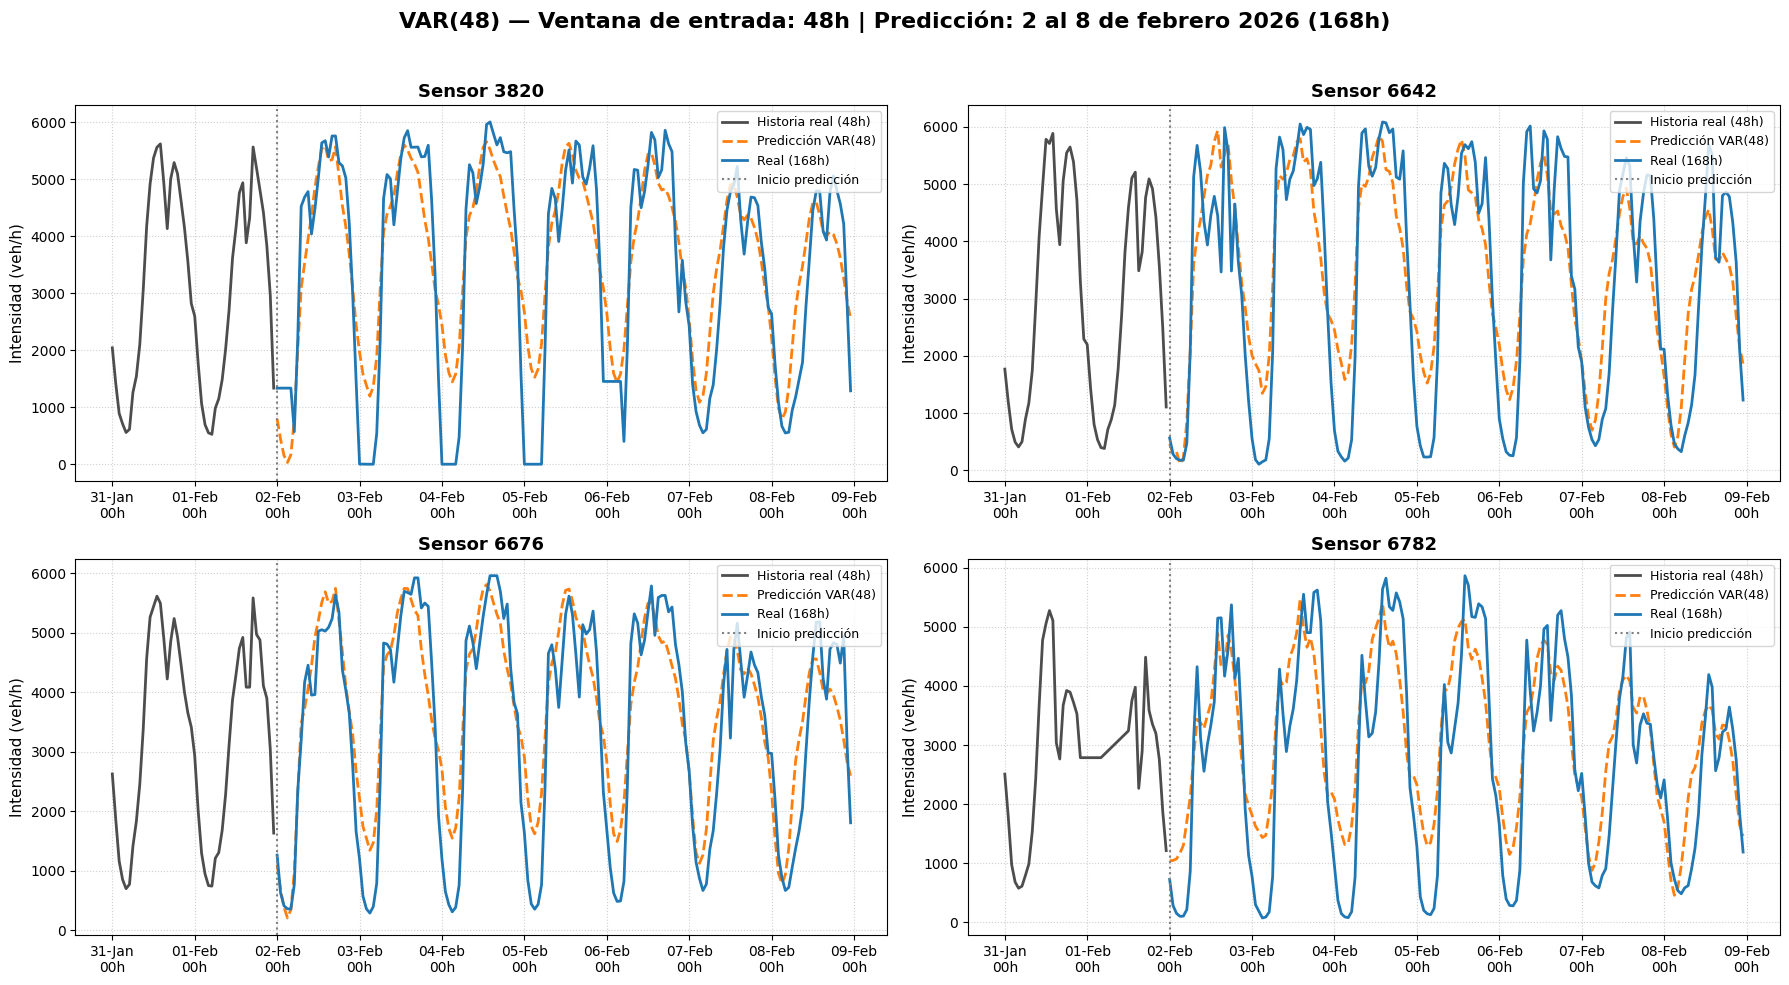

In [11]:
# =============================================================
# PASO 7: GRÁFICA SEMANA 2-8 FEBRERO 2026
# Ventana entrada: 48h previas | Salida: 168h predicción
# =============================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Definición de ventanas temporales ---
fecha_inicio_pred  = "2026-02-02"
fecha_fin_pred     = "2026-02-08 23:00:00"

# Historia: las 48h reales anteriores al 2 de febrero
# (pueden estar en test_df si el 1-ene está en test, lo están)
historia_real = test_df[cols_intensidad].loc[:"2026-02-01 23:00:00"].iloc[-lag_elegido:]

# Predicción: slice de df_pred_test_168 para la semana objetivo
# df_pred_test_168 arranca el 2026-01-01, necesitamos el offset hasta el 2 de febrero
idx_inicio = test_df.index.get_loc("2026-02-02 00:00:00")
horas_hasta_feb2 = idx_inicio  # número de horas desde inicio de test hasta el 2-feb

pred_semana = var_optimo.forecast(
    y=test_df[cols_endogenas].iloc[horas_hasta_feb2 - lag_elegido : horas_hasta_feb2].values,
    steps=168,
    exog_future=test_df[cols_exogenas].iloc[horas_hasta_feb2 : horas_hasta_feb2 + 168].values
)
df_pred_semana = pd.DataFrame(
    pred_semana,
    index=test_df.index[horas_hasta_feb2 : horas_hasta_feb2 + 168],
    columns=cols_endogenas
)

# Real de la semana objetivo
real_semana = test_df[cols_intensidad].loc[fecha_inicio_pred:fecha_fin_pred]

# --- Figura ---
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
fig.suptitle(
    f'VAR({lag_elegido}) — Ventana de entrada: {lag_elegido}h | '
    f'Predicción: 2 al 8 de febrero 2026 (168h)',
    fontsize=16, fontweight='bold', y=0.98
)
axes = axes.flatten()

for i, col in enumerate(cols_intensidad):
    ax = axes[i]
    sensor_id = col.split('_')[1]

    # Historia real (48h previas)
    ax.plot(
        historia_real.index, historia_real[col],
        color='#4d4d4d', linewidth=2, label='Historia real (48h)'
    )

    # Predicción VAR (168h)
    ax.plot(
        df_pred_semana.index, df_pred_semana[col],
        color='#ff7f0e', linewidth=2, linestyle='--',
        label=f'Predicción VAR({lag_elegido})'
    )

    # Real de la semana (168h)
    ax.plot(
        real_semana.index, real_semana[col],
        color='#1f77b4', linewidth=2, label='Real (168h)'
    )

    # Línea vertical de separación historia/predicción
    ax.axvline(
        x=pd.Timestamp("2026-02-02 00:00:00"),
        color='grey', linestyle=':', linewidth=1.5, label='Inicio predicción'
    )

    ax.set_title(f'Sensor {sensor_id}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Intensidad (veh/h)', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b\n%Hh'))
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right', fontsize=9)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

--- GENERANDO GRÁFICOS DE ALTA RESOLUCIÓN ---


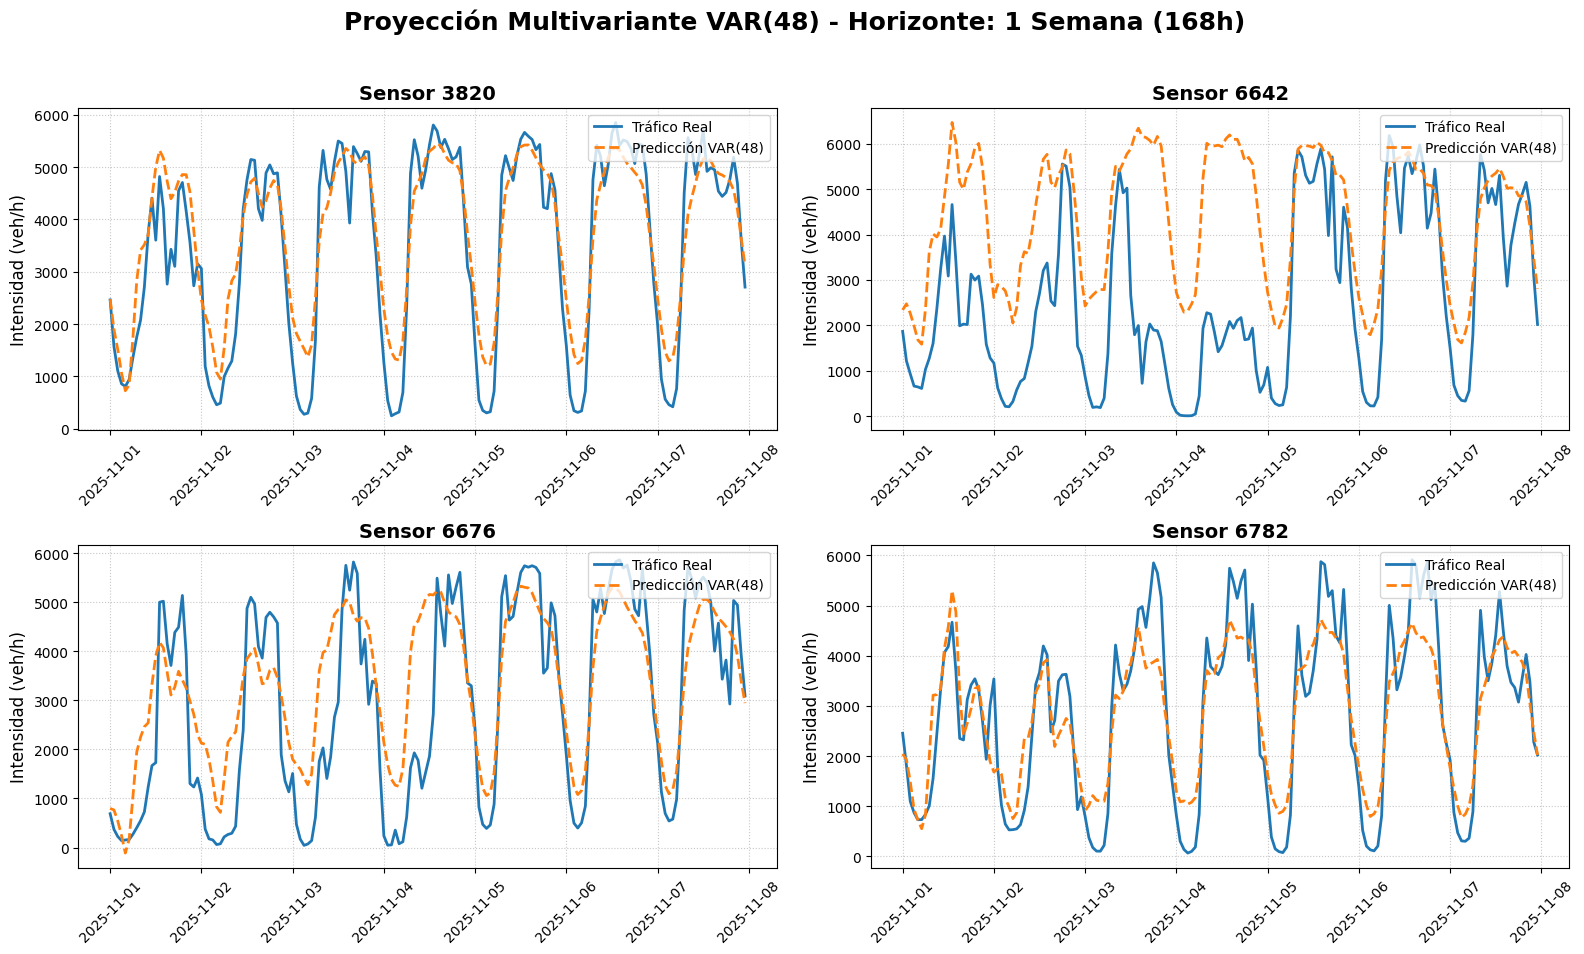

In [9]:
import matplotlib.pyplot as plt

print("--- GENERANDO GRÁFICOS DE ALTA RESOLUCIÓN ---")

# Configuramos el estilo del gráfico (limpio y académico)
plt.style.use('default')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

# CORRECCIÓN: Título dinámico que se adapta al lag elegido por el modelo
fig.suptitle(f'Proyección Multivariante VAR({lag_elegido}) - Horizonte: 1 Semana (168h)', 
             fontsize=18, fontweight='bold', y=0.95)

# Aplanamos la matriz de ejes para iterar fácilmente con un bucle
axes = axes.flatten()

# Iteramos sobre los 4 sensores de intensidad
for i, col in enumerate(cols_intensidad):
    ax = axes[i]
    
    # Extraemos el número del sensor para el título
    sensor_id = col.split('_')[1]
    
    # Extraemos los datos a dibujar
    real_data = val_df[col].iloc[:168]
    pred_data = df_pred_168[col]
    
    # Dibujamos las líneas
    ax.plot(real_data.index, real_data.values, label='Tráfico Real', color='#1f77b4', linewidth=2)
    ax.plot(pred_data.index, pred_data.values, label=f'Predicción VAR({lag_elegido})', color='#ff7f0e', linestyle='--', linewidth=2)
    
    # Personalización del sub-gráfico
    ax.set_title(f'Sensor {sensor_id}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Intensidad (veh/h)', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='upper right')
    
    # Rotamos las fechas para que se lean bien
    ax.tick_params(axis='x', rotation=45)

# Ajustamos el espaciado para que no se solapen los textos
plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.show()